# Phase 2 — Exploratory Data Analysis


**Input:**  `outputs/model_table.csv` -
**Output:** Engineered `model_table.csv` 

In [102]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [103]:
df=pd.read_csv("../outputs/model_table.csv")
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            25000 non-null  int64  
 1   age                   25000 non-null  int64  
 2   gender                25000 non-null  object 
 3   city                  25000 non-null  object 
 4   insurance_provider    25000 non-null  object 
 5   chronic_flag          25000 non-null  int64  
 6   registration_date     25000 non-null  object 
 7   visit_id              25000 non-null  int64  
 8   visit_date            25000 non-null  object 
 9   department            25000 non-null  object 
 10  visit_type            25000 non-null  object 
 11  length_of_stay_hours  25000 non-null  float64
 12  risk_score            25000 non-null  object 
 13  doctor_id             25000 non-null  int64  
 14  bill_id               25000 non-null  int64  
 15  billed_amount      

In [134]:
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [105]:
df.describe(include= "all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2509.51536,1.0,1249.0,2505.0,3764.0,5000.0,1448.68904
age,25000.0,NaN,NaN,NaN,44.76832,1.0,33.0,45.0,57.0,90.0,17.784232
gender,25000,2,F,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Hyderabad,4370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,MediCareX,6532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.5026,0.0,0.0,1.0,1.0,1.0,0.500003
registration_date,25000,NaN,NaN,NaN,2025-07-18 16:17:11.040000,2025-01-20 00:00:00,2025-04-16 00:00:00,2025-07-19 00:00:00,2025-10-19 00:00:00,2026-01-20 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-07-21 15:25:51.744000256,2025-01-20 00:00:00,2025-04-21 00:00:00,2025-07-21 00:00:00,2025-10-21 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,4228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution Analysis

### Step 1 - Missing Values Analysis

In [106]:
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
claim_status               0
billed_amount              0
bill_id                    0
doctor_id                  0
risk_score                 0
length_of_stay_hours       0
visit_type                 0
department                 0
visit_date                 0
visit_id                   0
registration_date          0
chronic_flag               0
insurance_provider         0
city                       0
gender                     0
billing_date               0
dtype: int64

In [107]:
df.head()

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
0,3993,9,M,Hyderabad,HealthPlus,1,2025-10-18,684,2025-01-20,General,ICU,5.79,Low,137,684,36721.68,36721.68,Paid,19.0,2025-08-15
1,76,59,M,Delhi,HealthPlus,0,2025-07-09,1412,2025-01-20,General,ER,34.80,Medium,109,1412,8365.47,4189.20,Pending,26.0,2025-11-14
2,3393,43,M,Hyderabad,HealthPlus,0,2025-07-10,1510,2025-01-20,ICU,ICU,31.37,Medium,135,1510,16529.35,0.00,Rejected,7.0,2025-04-24
3,1998,29,M,Bangalore,MediCareX,1,2025-04-22,1549,2025-01-20,Cardiology,ER,20.88,Medium,179,1549,61827.63,61827.63,Paid,1.0,2025-10-17
4,3500,38,M,Hyderabad,CareOne,1,2025-08-02,2275,2025-01-20,Orthopedics,ICU,4.97,Low,107,2275,5860.51,4897.65,Pending,28.0,2025-08-05


### Step 2 — Business Logic Validation


In [108]:
# Check A - Paid claims should always have an approved amount
df[
    (df["claim_status"]=="paid") &
    (df["approved_amount"].isna())

].shape

(0, 20)

In [109]:
# Check B - payment days missing breakdown by claim status
df[df["payment_days"].isna()]["claim_status"].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

In [110]:
# Check C - LOS should never be negative
(df["length_of_stay_hours"]<0).sum()

0

### Step 3 — Distribution Analysis

In [111]:
# Categorical column reports
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

======Visit Type=================
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

=======City=======================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


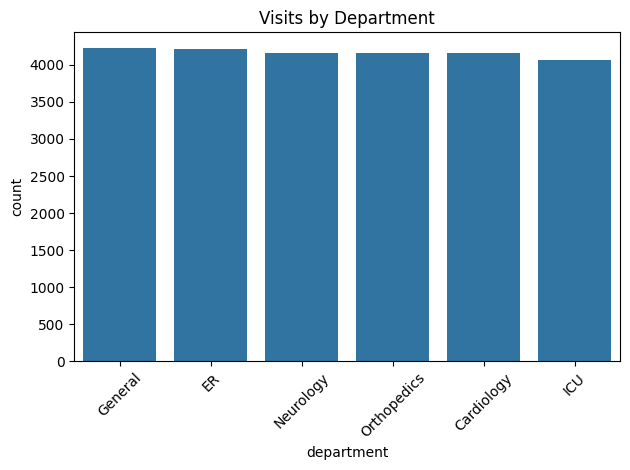

In [112]:
# Barchart showing visits by department
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

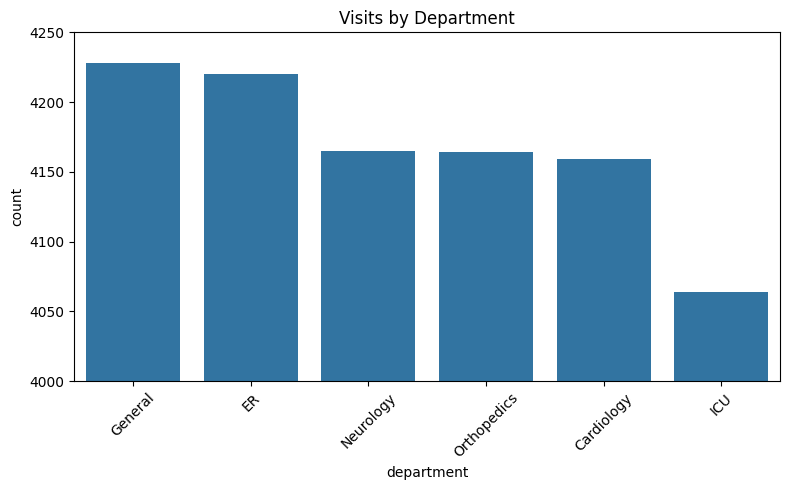

In [113]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="department",
    order=df["department"].value_counts().index
)

plt.ylim(4000, 4250)  # Zoom in
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

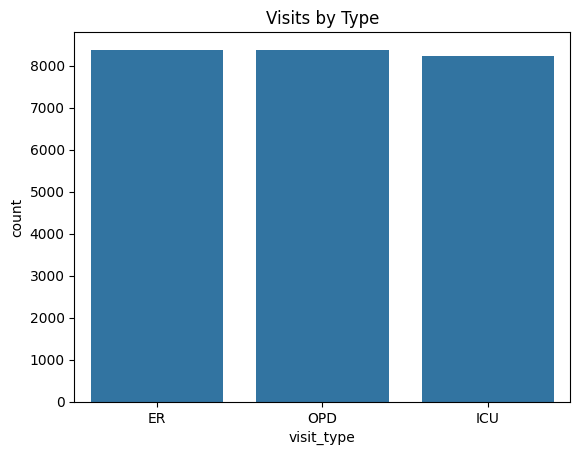

In [114]:
# Visits by Type
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.show()

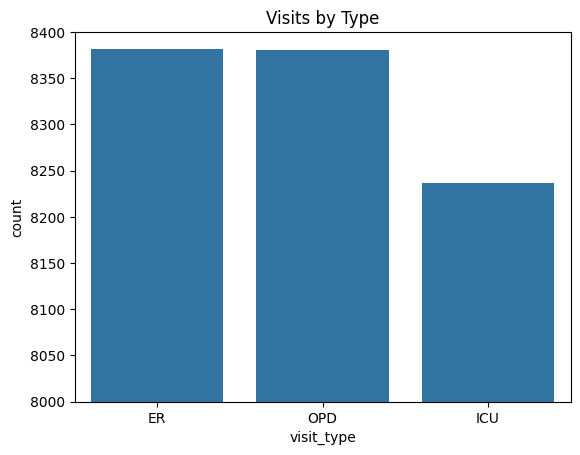

In [115]:
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.ylim(8000, 8400)  # Zoom in
plt.show()

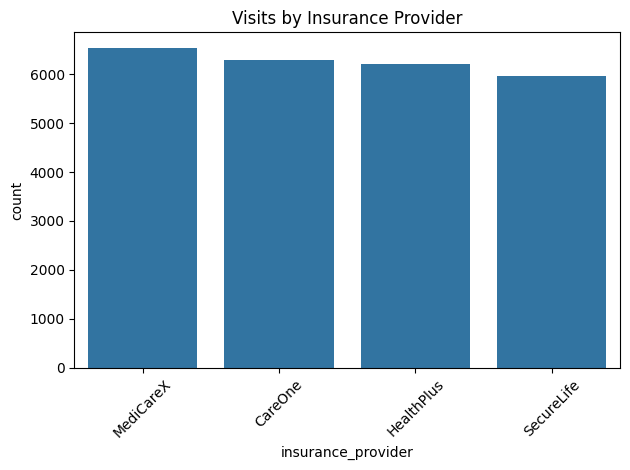

In [116]:
sns.countplot(data=df, x="insurance_provider", order=df["insurance_provider"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Insurance Provider")
plt.tight_layout()
plt.show()

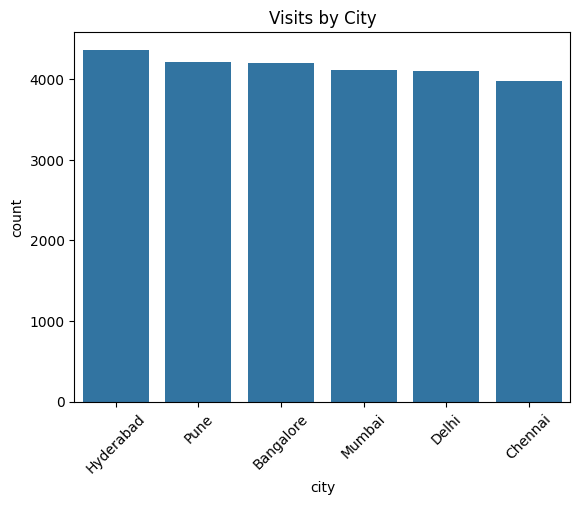

In [117]:
# Visits by City
sns.countplot(
    data=df,
    x="city",
    order=df["city"].value_counts().index
)
plt.title("Visits by City")
plt.xticks(rotation=45)
plt.show()

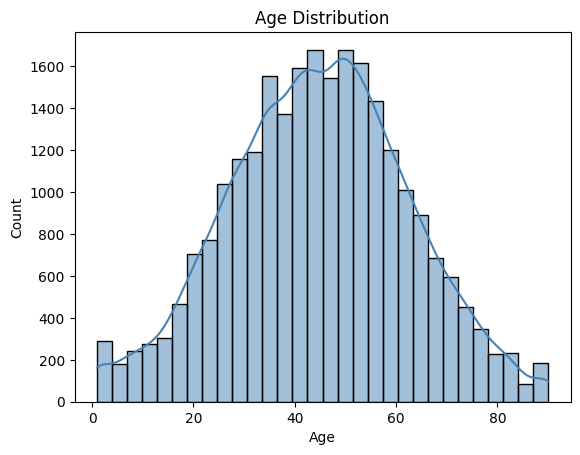

count    25000.000000
mean        44.768320
std         17.784232
min          1.000000
25%         33.000000
50%         45.000000
75%         57.000000
max         90.000000
Name: age, dtype: float64


In [118]:
# Age Dsitribution
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe())


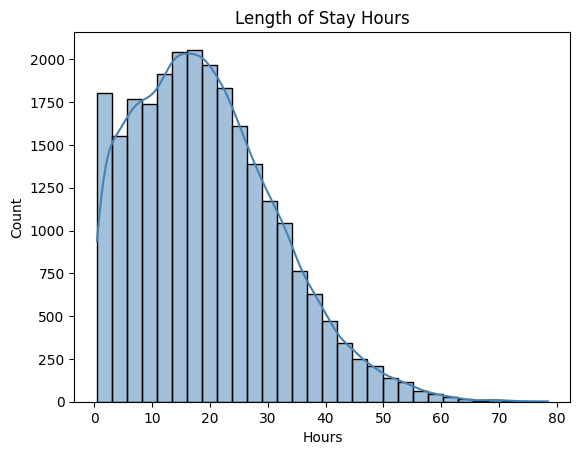

count    25000.00
mean        19.55
std         12.31
min          0.50
25%          9.96
50%         18.20
75%         27.31
max         78.42
Name: length_of_stay_hours, dtype: float64


In [119]:
# Length of Stay Distribution
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [120]:
firstIQR=9.96
thirdIQR=27.31
IQR=thirdIQR-firstIQR
upper_bound=thirdIQR+(1.5*IQR) 
print(f"Upper bound for LOS hours: {upper_bound:.2f}")
lower_bound=firstIQR-(1.5*IQR)
print(f"Lower bound for LOS hours: {lower_bound:.2f}")

Upper bound for LOS hours: 53.33
Lower bound for LOS hours: -16.06


## Outlier Detection

### Step 4 — Outlier Detection

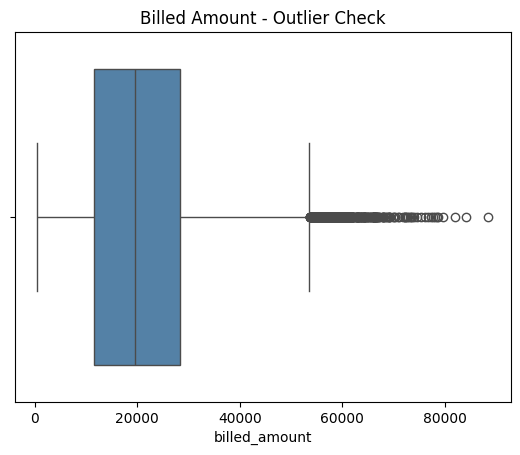

In [121]:
sns.boxplot(x=df["billed_amount"], color="steelblue")
plt.title("Billed Amount - Outlier Check") # Focus on typical range
plt.show()

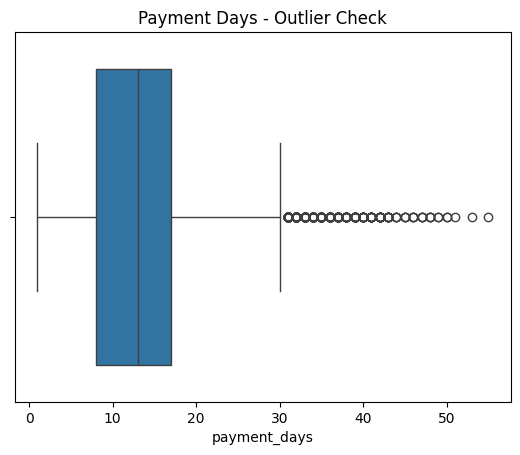

In [122]:
sns.boxplot(x=df["payment_days"])
plt.title("Payment Days - Outlier Check")
plt.show()

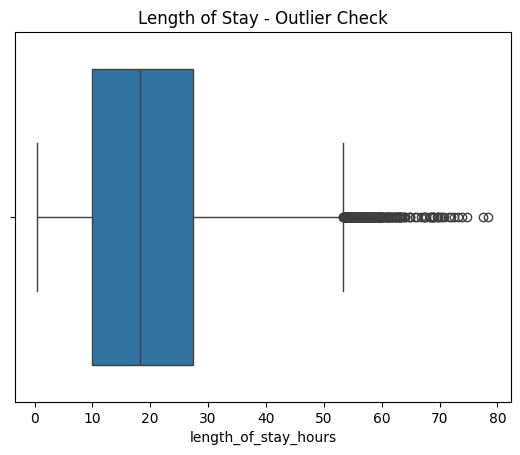

In [123]:
sns.boxplot(x=df["length_of_stay_hours"])
plt.title("Length of Stay - Outlier Check")
plt.show()

In [124]:
df=pd.read_csv("../outputs/model_table.csv")
for col in ["length_of_stay_hours", "billed_amount", "payment_days"]:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f"  Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
    print(f"  Lower bound = {lower:.1f}  |  Upper bound = {upper:.1f}")
    print(f"  Outliers    = {n_out} rows")
    print()

length_of_stay_hours
  Q1 = 10.0  |  Q3 = 27.3  |  IQR = 17.4
  Lower bound = -16.1  |  Upper bound = 53.3
  Outliers    = 256 rows

billed_amount
  Q1 = 11582.5  |  Q3 = 28398.1  |  IQR = 16815.6
  Lower bound = -13641.0  |  Upper bound = 53621.5
  Outliers    = 373 rows

payment_days
  Q1 = 8.0  |  Q3 = 17.0  |  IQR = 9.0
  Lower bound = -5.5  |  Upper bound = 30.5
  Outliers    = 509 rows



## Note

In the medical domain, negative lower bounds are not considered meaningful, so the lower bound is typically capped at 0.

## Feature Correlations

# We encode the target variables numerically so we can measure correlation.

- `risk_score`  → Low=0, Medium=1, High=2
- `claim_status` → Paid=0, Pending=1, Rejected=2

In [125]:
df["risk_numeric"] = df["risk_score"].map({"Low": 0, "Medium": 1, "High": 2})
df["claim_status_numeric"] = df["claim_status"].map({"Paid": 0, "Pending": 1, "Rejected": 2})
print("risk_numeric :",  {"Low": 0, "Medium": 1, "High": 2})
print("claim_numeric :", {"Paid": 0, "Pending": 1, "Rejected": 2})


risk_numeric : {'Low': 0, 'Medium': 1, 'High': 2}
claim_numeric : {'Paid': 0, 'Pending': 1, 'Rejected': 2}


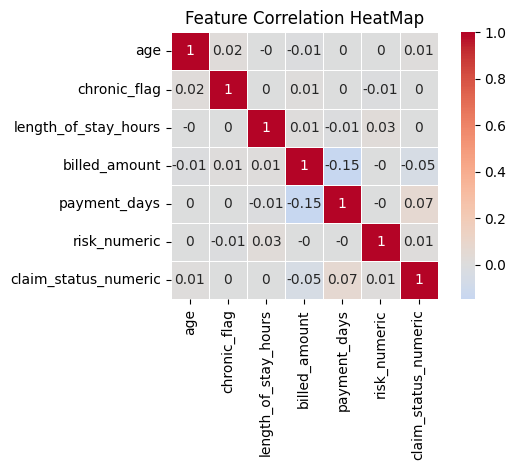

In [126]:

# Full correlation heatmap
numeric_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_status_numeric"
]
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidth=0.5, square=True)
plt.title("Feature Correlation HeatMap")
plt.tight_layout()
plt.show()


In [127]:
corr_risk = corr["risk_numeric"].drop("risk_numeric")

print("Correlation with risk_score (sorted):")
print(corr_risk.sort_values(ascending=False).round(3))

Correlation with risk_score (sorted):
length_of_stay_hours    0.03
claim_status_numeric    0.01
age                     0.00
billed_amount          -0.00
payment_days           -0.00
chronic_flag           -0.01
Name: risk_numeric, dtype: float64


In [128]:
corr_claim = corr["claim_status_numeric"].drop("claim_status_numeric")

print("Correlation with claim_status (sorted):")
print(corr_claim.sort_values(ascending=False).round(3))

Correlation with claim_status (sorted):
payment_days            0.07
age                     0.01
risk_numeric            0.01
chronic_flag            0.00
length_of_stay_hours    0.00
billed_amount          -0.05
Name: claim_status_numeric, dtype: float64


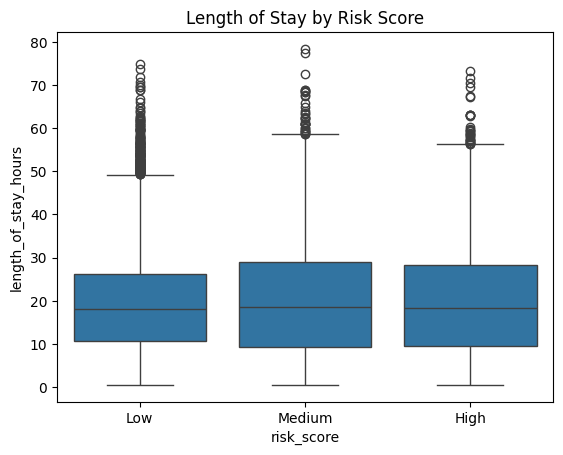


Mean LOS by Risk Score:
risk_score
High      19.76
Low       19.15
Medium    20.08
Name: length_of_stay_hours, dtype: float64


In [129]:
sns.boxplot(data=df, x="risk_score", y="length_of_stay_hours",order=["Low", "Medium", "High"])
plt.title("Length of Stay by Risk Score")
plt.show()
print("\nMean LOS by Risk Score:")
print(df.groupby("risk_score")["length_of_stay_hours"]
  .mean().round(2))

Rejection Rate by Insurance Provider (%):
insurance_provider
SecureLife    15.7
MediCareX     15.2
HealthPlus    15.0
CareOne       14.9
Name: is_rejected, dtype: float64


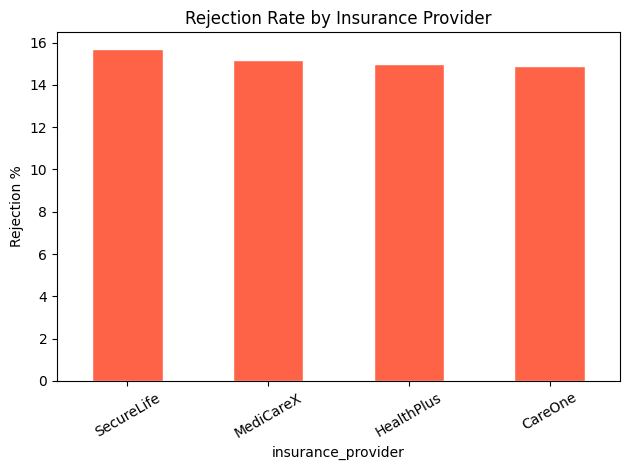

In [130]:
df["is_rejected"] = (df["claim_status"] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"]
            .mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 7 — Feature Engineering

We create 7 new features from the existing columns.  
These features encode **patient behaviour** and **provider patterns**  
that the raw columns cannot express on their own.

| Feature | Logic | Why it matters |
|---|---|---|
| days_since_registration | visit_date − registration_date | Long-term patients behave differently |
| visit_frequency | count of visits per patient | Frequent visitors = higher utilisation |
| avg_los_per_patient | mean LOS per patient | Patient-level health baseline |
| is_rejected | 1 if Rejected else 0 | Helper for rejection rate |
| provider_rejection_rate | mean rejection per insurer | Encodes insurer behaviour |
| visit_month | month from visit_date | Seasonality signal |
| visit_dayofweek | day of week from visit_date | Operational pattern |
| high_cost_visit_flag | billed > 75th percentile | Flags expensive visits |

In [137]:

df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   patient_id               25000 non-null  int64         
 1   age                      25000 non-null  int64         
 2   gender                   25000 non-null  object        
 3   city                     25000 non-null  object        
 4   insurance_provider       25000 non-null  object        
 5   chronic_flag             25000 non-null  int64         
 6   registration_date        25000 non-null  datetime64[ns]
 7   visit_id                 25000 non-null  int64         
 8   visit_date               25000 non-null  datetime64[ns]
 9   department               25000 non-null  object        
 10  visit_type               25000 non-null  object        
 11  length_of_stay_hours     25000 non-null  float64       
 12  risk_score               25000 n

In [142]:
# Days since registration
df["days_since_registration"] = abs(
    df["visit_date"] - df["registration_date"]
).dt.days

df[["patient_id", "visit_date",
    "registration_date", "days_since_registration"]].head()

,patient_id,visit_date,registration_date,days_since_registration
0,3993,2025-01-20,2025-10-18,271
1,76,2025-01-20,2025-07-09,170
2,3393,2025-01-20,2025-07-10,171
3,1998,2025-01-20,2025-04-22,92
4,3500,2025-01-20,2025-08-02,194


In [140]:
# Visit frequency per patient
df["visit_frequency"] = df.groupby("patient_id")["visit_id"].transform("count")

df[["patient_id", "visit_frequency"]].drop_duplicates().head(10)


,patient_id,visit_frequency
0,3993,4
1,76,5
2,3393,8
3,1998,11
4,3500,7
5,3286,7
6,152,5
7,532,6
8,4451,7
9,2826,7


In [143]:
# Average LOS per patient
df["avg_los_per_patient"] = df.groupby("patient_id")["length_of_stay_hours"].transform("mean")

df[["patient_id", "length_of_stay_hours",
    "avg_los_per_patient"]].head()

,patient_id,length_of_stay_hours,avg_los_per_patient
0,3993,5.79,12.645000
1,76,34.80,22.330000
2,3393,31.37,24.091250
3,1998,20.88,18.974545
4,3500,4.97,21.358571


In [144]:
# Provider rejection rate

df["provider_rejection_rate"] = df.groupby("insurance_provider")["is_rejected"].transform("mean")

print("Rejection rate per provider:")
print(df.groupby("insurance_provider")["provider_rejection_rate"]
      .first().round(3))

Rejection rate per provider:
insurance_provider
CareOne       0.149
HealthPlus    0.150
MediCareX     0.152
SecureLife    0.157
Name: provider_rejection_rate, dtype: float64


In [145]:
# Time-based features
df["visit_month"]      = df["visit_date"].dt.month
df["visit_dayofweek"]  = df["visit_date"].dt.dayofweek

df[["visit_date", "visit_month", "visit_dayofweek"]].head()

,visit_date,visit_month,visit_dayofweek
0,2025-01-20,1,0
1,2025-01-20,1,0
2,2025-01-20,1,0
3,2025-01-20,1,0
4,2025-01-20,1,0


In [146]:
# High cost visit flag — top 25% of billed amount
high_cost_threshold = df["billed_amount"].quantile(0.75)
df["high_cost_visit_flag"] = (df["billed_amount"] > high_cost_threshold).astype(int)

print(f"High cost threshold (75th percentile): ₹{high_cost_threshold:,.0f}")
print()
print(df["high_cost_visit_flag"].value_counts())

High cost threshold (75th percentile): ₹28,398

high_cost_visit_flag
0    18750
1     6250
Name: count, dtype: int64


In [147]:
# Final feature check
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

print("New features added:")
for f in new_features:
    print(f"  ✓ {f}")

print(f"\nFinal dataset shape: {df.shape}")

New features added:
  ✓ days_since_registration
  ✓ visit_frequency
  ✓ avg_los_per_patient
  ✓ provider_rejection_rate
  ✓ visit_month
  ✓ visit_dayofweek
  ✓ high_cost_visit_flag

Final dataset shape: (25000, 30)


In [148]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.0,25000.00
mean,121.13,5.96,19.55,0.15,6.52,3.0,0.25
std,86.28,2.18,5.51,0.00,3.46,2.0,0.43
min,0.00,1.00,0.50,0.15,1.00,0.0,0.00
25%,48.00,4.00,15.93,0.15,4.00,1.0,0.00
50%,106.00,6.00,19.20,0.15,7.00,3.0,0.00
75%,183.00,7.00,22.84,0.15,10.00,5.0,0.25
max,364.00,15.00,56.23,0.16,12.00,6.0,1.00
